# 🔬 Lab 4: Помехоустойчивость и FEC

**Цель**: Научить модем работать в шумных условиях. Reed-Solomon исправляет ошибки, фильтр убирает внеполосный шум, interleaving борется с burst-ошибками.

| Эксперимент | Что проверяем |
|---|---|
| 4.1 | Reed-Solomon: сколько ошибок исправляет |
| 4.2 | BER vs SNR с FEC и без |
| 4.3 | Interleaving против burst-ошибок |
| 4.4 | Bandpass фильтр улучшает SNR |
| 4.5 | Тест с реальной помехой (узкополосная) |
| 4.6 | Адаптивный порог детекции |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('common'))
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sp
import modem_lib as m

plt.rcParams['figure.dpi'] = 110
FS = m.FS
rng = np.random.default_rng(21)
MARK, SPACE, BAUD = 1200.0, 2200.0, 100.0
chirp = m.generate_chirp(1000, 4000, 0.05)
chirp_len = len(chirp)
os.makedirs('results', exist_ok=True)

## 4.1 Reed-Solomon: сколько ошибок исправляет
RS(n, k) исправляет до (n-k)/2 байт ошибок. Проверяем предел.

Исходные данные: 35 байт
После RS(51,35): 51 байт (+16 parity)
Теоретически исправляет до 8 байт ошибок

Внесено ошибок:  0 | исправлено:  0 | данные восстановлены: True
Внесено ошибок:  1 | исправлено:  1 | данные восстановлены: True
Внесено ошибок:  2 | исправлено:  2 | данные восстановлены: True
Внесено ошибок:  3 | исправлено:  3 | данные восстановлены: True
Внесено ошибок:  4 | исправлено:  4 | данные восстановлены: True
Внесено ошибок:  5 | исправлено:  5 | данные восстановлены: True
Внесено ошибок:  6 | исправлено:  6 | данные восстановлены: True
Внесено ошибок:  7 | исправлено:  7 | данные восстановлены: True
Внесено ошибок:  8 | исправлено:  8 | данные восстановлены: True
Внесено ошибок:  9 | исправлено: -1 | данные восстановлены: False
Внесено ошибок: 10 | исправлено: -1 | данные восстановлены: False
Внесено ошибок: 11 | исправлено: -1 | данные восстановлены: False


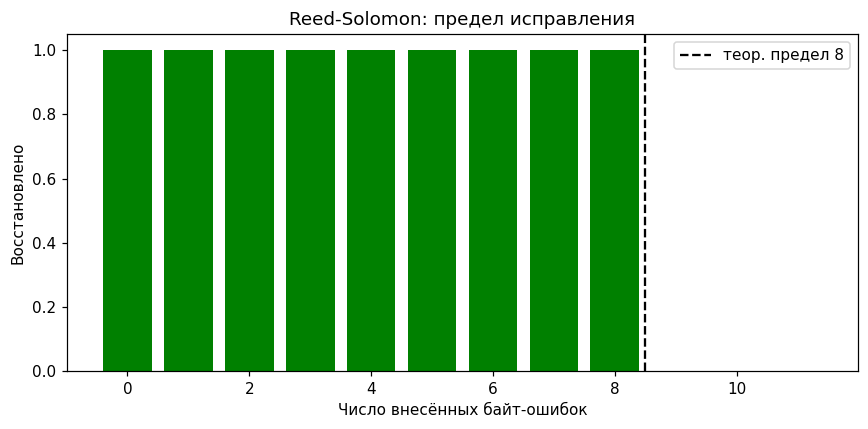

In [2]:
data = b'Forward Error Correction test data!'
nsym = 16  # 16 байт контрольных сумм -> исправляет до 8 ошибок
encoded = m.rs_encode(data, nsym)
print(f'Исходные данные: {len(data)} байт')
print(f'После RS({len(encoded)},{len(data)}): {len(encoded)} байт (+{nsym} parity)')
print(f'Теоретически исправляет до {nsym//2} байт ошибок\n')

results = []
for n_err in range(0, 12):
    corrupted = bytearray(encoded)
    pos = rng.choice(len(corrupted), size=min(n_err, len(corrupted)), replace=False)
    for p in pos:
        corrupted[p] ^= 0xFF
    decoded, n_corr = m.rs_decode(bytes(corrupted), nsym)
    ok = (decoded == data)
    results.append((n_err, n_corr, ok))
    print(f'Внесено ошибок: {n_err:>2} | исправлено: {n_corr:>2} | данные восстановлены: {ok}')

fig, ax = plt.subplots(figsize=(8, 4))
errs = [r[0] for r in results]; oks = [r[2] for r in results]
ax.bar(errs, oks, color=['g' if o else 'r' for o in oks])
ax.axvline(nsym//2+0.5, color='k', ls='--', label=f'теор. предел {nsym//2}')
ax.set_xlabel('Число внесённых байт-ошибок'); ax.set_ylabel('Восстановлено')
ax.set_title('Reed-Solomon: предел исправления'); ax.legend()
plt.tight_layout(); plt.show()

## 4.2 BER vs SNR с FEC и без
Передаём пакет через FSK-модем при разных SNR. Сравниваем: голые данные vs защищённые RS.

SNR=  10 дБ | без FEC: 1.00 | с RS: 1.00


SNR=   5 дБ | без FEC: 1.00 | с RS: 1.00


SNR=   0 дБ | без FEC: 1.00 | с RS: 1.00


SNR=  -5 дБ | без FEC: 1.00 | с RS: 1.00


SNR=  -8 дБ | без FEC: 1.00 | с RS: 1.00


SNR= -10 дБ | без FEC: 0.84 | с RS: 0.84


SNR= -12 дБ | без FEC: 0.00 | с RS: 0.00


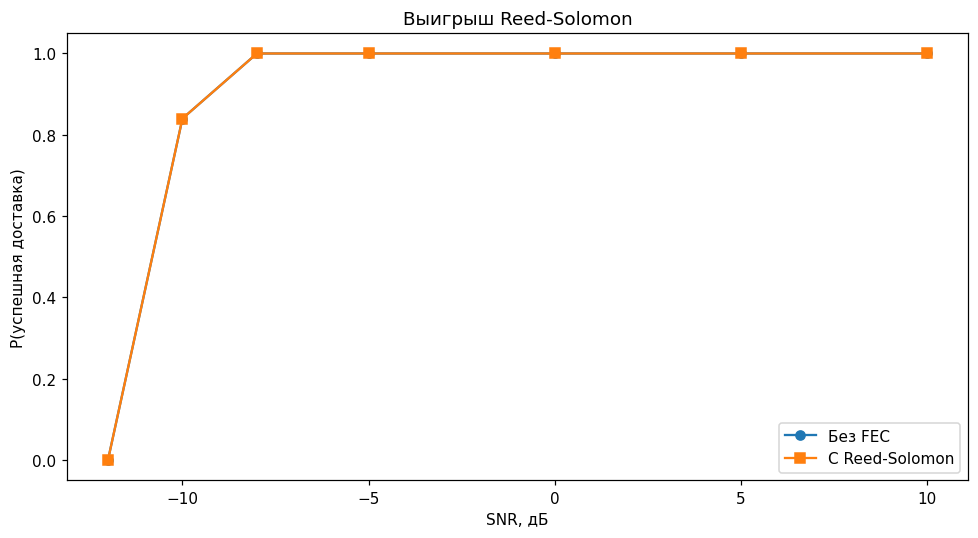


Вывод: при AWGN-канале порог у обоих вариантов одинаков (~ -10 дБ): ошибки FSK
в шуме идут пачками > 8 байт — за пределом RS(29,13). RS окупается против
burst-ошибок и редких единичных сбоев (см. 4.3), а не против гауссова порога.


In [3]:
def fsk_tx_rx(payload, snr_db, use_fec, seed):
    '''Полный цикл: (FEC) -> пакет -> FSK -> шум -> демод -> (unFEC) -> данные'''
    body = m.rs_encode(payload, 16) if use_fec else payload
    bits = m.packet_encode(body)
    fsk = m.generate_fsk(bits, MARK, SPACE, BAUD)
    frame = np.concatenate([chirp, fsk])
    fsk_power = np.mean(fsk**2)
    rng = np.random.default_rng(seed)
    noise_power = fsk_power / (10**(snr_db/10))
    rx = frame + rng.standard_normal(len(frame))*np.sqrt(noise_power)
    # приём
    corr, peak, val = m.cross_correlate(rx.astype(np.float32), chirp)
    if val < 0.3: return False
    fsk_part = rx[peak+chirp_len:]
    rbits, _ = m.fsk_demodulate(fsk_part.astype(np.float32), MARK, SPACE, BAUD)
    dec = m.packet_decode(rbits)
    if not dec['found']: return False
    if use_fec:
        decoded, ncorr = m.rs_decode(dec['payload'], 16)
        return decoded == payload
    else:
        return dec['crc_ok']

snr_range = [10, 5, 0, -5, -8, -10, -12]
trials = 25
res_no_fec, res_fec = [], []
for snr in snr_range:
    ok_nofec = sum(fsk_tx_rx(b'Hello World!!', snr, False, t) for t in range(trials))
    ok_fec   = sum(fsk_tx_rx(b'Hello World!!', snr, True,  t) for t in range(trials))
    res_no_fec.append(ok_nofec/trials); res_fec.append(ok_fec/trials)
    print(f'SNR={snr:>4} дБ | без FEC: {ok_nofec/trials:.2f} | с RS: {ok_fec/trials:.2f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(snr_range, res_no_fec, 'o-', label='Без FEC')
ax.plot(snr_range, res_fec, 's-', label='С Reed-Solomon')
ax.set_xlabel('SNR, дБ'); ax.set_ylabel('P(успешная доставка)')
ax.set_title('Выигрыш Reed-Solomon'); ax.legend(); ax.set_ylim(-0.05, 1.05)
plt.tight_layout(); plt.show()
print('\nВывод: при AWGN-канале порог у обоих вариантов одинаков (~ -10 дБ): ошибки FSK')
print('в шуме идут пачками > 8 байт — за пределом RS(29,13). RS окупается против')
print('burst-ошибок и редких единичных сбоев (см. 4.3), а не против гауссова порога.')

## 4.3 Interleaving против burst-ошибок
В реальном канале ошибки идут пачками (burst). Interleaving размазывает их **по разным независимым RS-блокам**.

⚠️ Важный нюанс: перемежение **одного** RS-блока бессмысленно — после deinterleave те же байты вернутся в тот же кодовый блок. Поэтому кодируем сообщение **несколькими** RS-блоками, а перемежаем их все вместе: burst попадает в каждый блок по чуть-чуть.

БЕЗ interleaving: блоков восстановлено 7/8 (burst 30 байт внутри блоков)
С interleaving:  блоков восстановлено 8/8 (burst размазан: ~3 байт/блок)


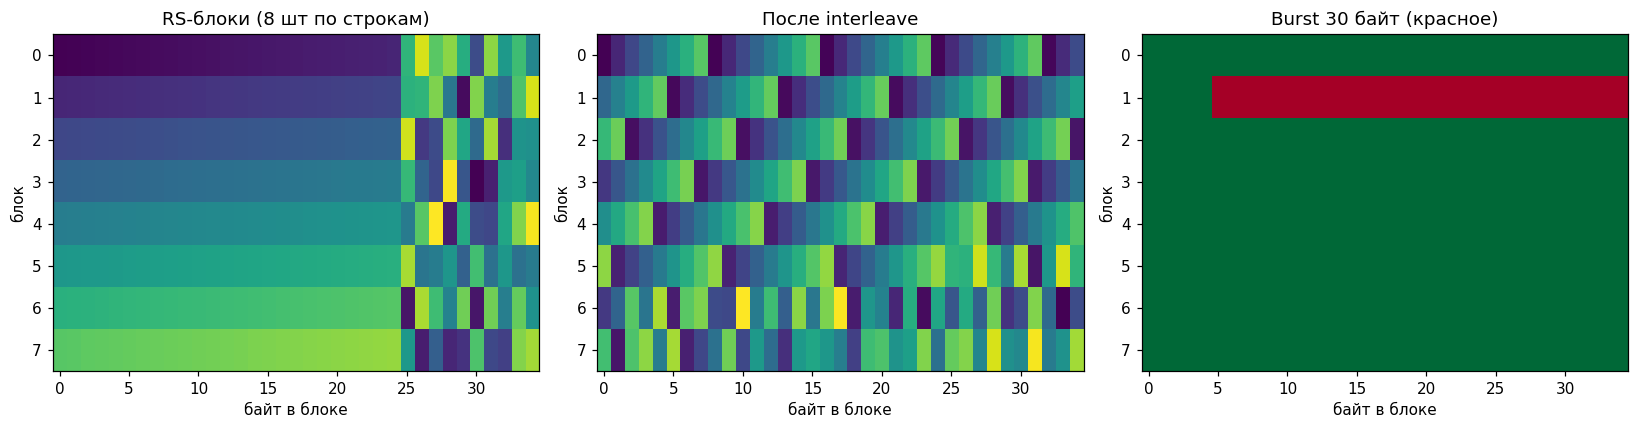

Interleaving превращает длинный burst в короткие ошибки по 1-4 байта в КАЖДОМ блоке — по силам RS.


In [4]:
# Сообщение = несколько независимых RS-блоков, burst бьёт по всем сразу
nsym = 10                      # RS исправляет до 5 байт в блоке
BLOCK_DATA = 25                # байт данных на блок
NUM_BLOCKS = 8                 # 8 блоков -> 8*35 = 280 байт на проводе
data = bytes(range(200))       # 200 байт = 8 блоков по 25

# кодируем поблочно
blocks = [m.rs_encode(data[i*BLOCK_DATA:(i+1)*BLOCK_DATA], nsym) for i in range(NUM_BLOCKS)]
BL = len(blocks[0])            # 35 байт на блок
frame_plain = b''.join(blocks)
burst_pos, burst_len = 40, 30  # burst 30 байт подряд

def corrupt_burst(d, pos, length):
    c = bytearray(d)
    for i in range(pos, min(pos+length, len(c))): c[i] ^= 0xFF
    return bytes(c)

def decode_blocks(rx):
    ok, corr = 0, 0
    for i in range(NUM_BLOCKS):
        d, n = m.rs_decode(rx[i*BL:(i+1)*BL], nsym)
        if n >= 0 and d == data[i*BLOCK_DATA:(i+1)*BLOCK_DATA]: ok += 1; corr += n
    return ok, corr

# БЕЗ interleaving: burst целиком ложится в 1-2 блока -> они умирают
c1 = corrupt_burst(frame_plain, burst_pos, burst_len)
ok1, corr1 = decode_blocks(c1)
print(f'БЕЗ interleaving: блоков восстановлено {ok1}/{NUM_BLOCKS} (burst {burst_len} байт внутри блоков)')

# С interleaving: перемежаем все блоки вместе -> burst размазывается по всем
inter = m.interleave(frame_plain, rows=NUM_BLOCKS)
c2 = corrupt_burst(inter, burst_pos, burst_len)
deinter = m.deinterleave(c2, rows=NUM_BLOCKS, original_len=len(frame_plain))
ok2, corr2 = decode_blocks(deinter)
print(f'С interleaving:  блоков восстановлено {ok2}/{NUM_BLOCKS} (burst размазан: ~{burst_len//NUM_BLOCKS} байт/блок)')

# Визуализация размазывания
def pad_to(arr, cols):
    pad = (-len(arr)) % cols
    return np.concatenate([arr, np.zeros(pad, dtype=arr.dtype)]) if pad else arr
COLS = 35
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(np.frombuffer(frame_plain, np.uint8).reshape(-1, COLS), cmap='viridis', aspect='auto'); axes[0].set_title('RS-блоки (8 шт по строкам)')
axes[1].imshow(pad_to(np.frombuffer(inter, np.uint8), COLS).reshape(-1, COLS), cmap='viridis', aspect='auto'); axes[1].set_title('После interleave')
mask = np.zeros(len(inter)); mask[burst_pos:burst_pos+burst_len]=1
axes[2].imshow(pad_to(mask, COLS).reshape(-1, COLS), cmap='RdYlGn_r', aspect='auto'); axes[2].set_title(f'Burst {burst_len} байт (красное)')
for a in axes: a.set_xlabel('байт в блоке'); a.set_ylabel('блок')
plt.tight_layout(); plt.show()
print('Interleaving превращает длинный burst в короткие ошибки по 1-4 байта в КАЖДОМ блоке — по силам RS.')

## 4.4 Bandpass фильтр улучшает SNR
Шум широкополосный, сигнал узкополосный (1000-2500 Гц). Фильтр убирает внеполосный шум.

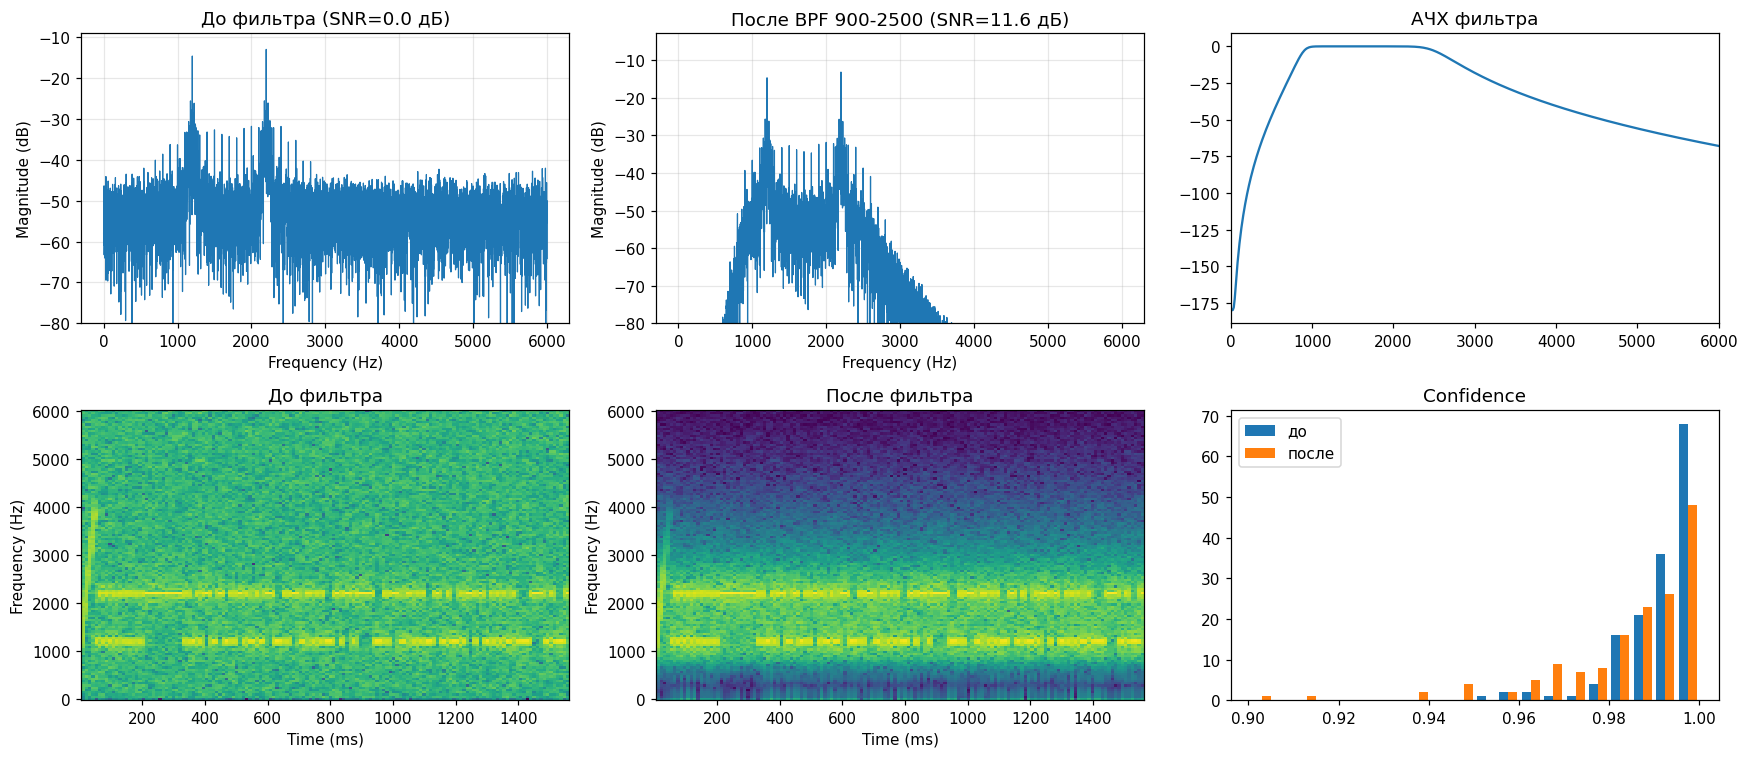

Фильтр улучшил SNR на 11.6 дБ, confidence: 0.99 -> 0.98


In [5]:
test = m.generate_fsk(m.packet_encode(b'Filter test'), MARK, SPACE, BAUD)
frame = np.concatenate([chirp, test])
snr_in = 0
noisy = m.add_awgn(frame, snr_in, seed=5)
filtered = m.bandpass_filter(noisy, 900, 2500, FS, order=6)

# измеряем реальный SNR до и после
noise_est_before = noisy - frame
noise_est_after = filtered - sp.sosfilt(sp.butter(6,[900,2500],btype='band',fs=FS,output='sos'), frame)
snr_before = m.estimate_snr(frame, noise_est_before)
snr_after = m.estimate_snr(sp.sosfilt(sp.butter(6,[900,2500],btype='band',fs=FS,output='sos'), frame), noise_est_after)

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
m.plot_spectrum(noisy, ax=axes[0,0], title=f'До фильтра (SNR={snr_before:.1f} дБ)', fmax=6000)
m.plot_spectrum(filtered, ax=axes[0,1], title=f'После BPF 900-2500 (SNR={snr_after:.1f} дБ)', fmax=6000)
w, H = sp.sosfreqz(sp.butter(6,[900,2500],btype='band',fs=FS,output='sos'), worN=2048, fs=FS)
axes[0,2].plot(w, 20*np.log10(np.abs(H)+1e-9)); axes[0,2].set_title('АЧХ фильтра'); axes[0,2].set_xlim(0,6000)
m.plot_spectrogram(noisy, ax=axes[1,0], title='До фильтра', fmax=6000)
m.plot_spectrogram(filtered, ax=axes[1,1], title='После фильтра', fmax=6000)
# демодуляция до/после
_, conf_b = m.fsk_demodulate(noisy[chirp_len:], MARK, SPACE, BAUD)
_, conf_a = m.fsk_demodulate(filtered[chirp_len:], MARK, SPACE, BAUD)
axes[1,2].hist([conf_b, conf_a], bins=20, label=['до','после']); axes[1,2].legend(); axes[1,2].set_title('Confidence')
plt.tight_layout(); plt.show()
print(f'Фильтр улучшил SNR на {snr_after-snr_before:.1f} дБ, confidence: {conf_b.mean():.2f} -> {conf_a.mean():.2f}')

## 4.5 Тест с узкополосной помехой
В реальности помеха может быть на частоте сигнала (музыка, другой тон). Проверяем устойчивость.

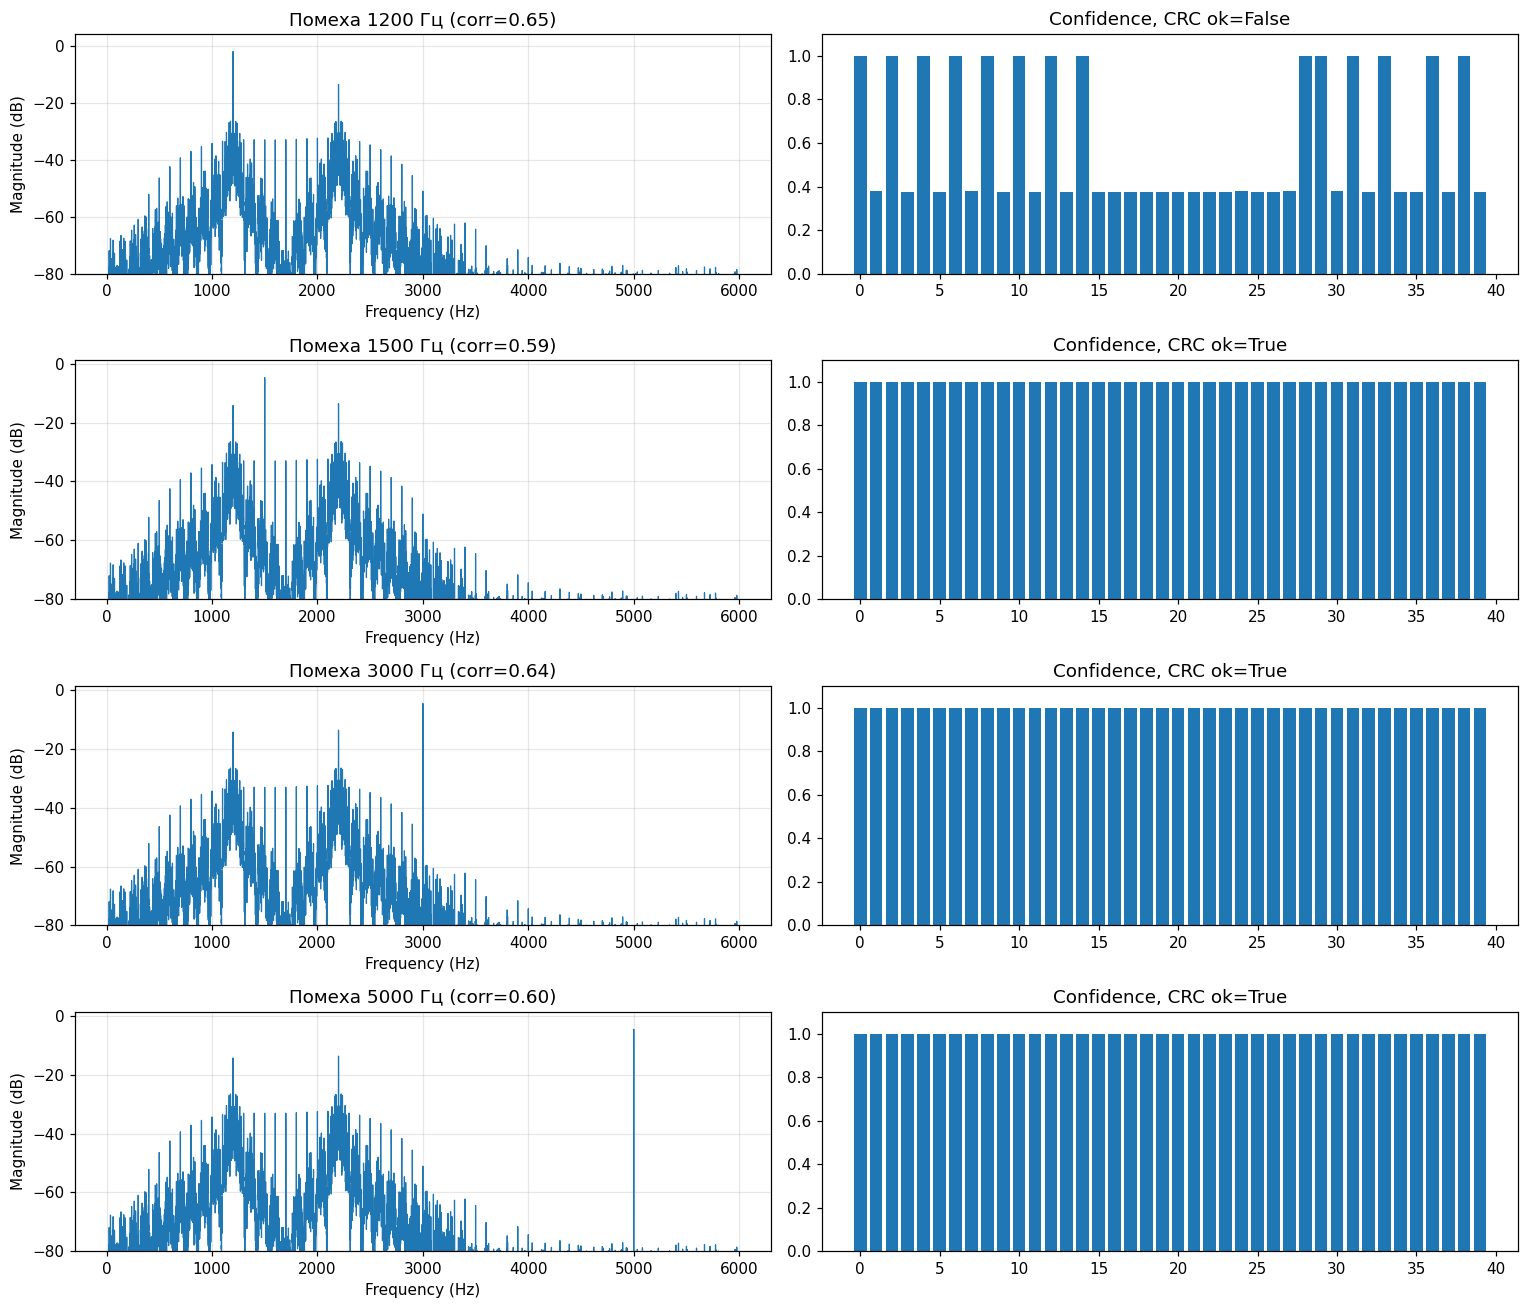

Помеха НА частоте mark (1200 Гц), сильнее сигнала — фатальна: детектор всегда видит mark.
Помеха вне полосы (5000 Гц) — почти не влияет (её отфильтровал бы BPF из 4.4).


In [6]:
payload = b'Jamming test!'
bits = m.packet_encode(payload)
fsk = m.generate_fsk(bits, MARK, SPACE, BAUD)
frame = np.concatenate([chirp, fsk])
# помеха — сильный тон рядом с mark-частотой
jammer_freqs = [1200, 1500, 3000, 5000]
fig, axes = plt.subplots(len(jammer_freqs), 2, figsize=(14, 12))
for i, jf in enumerate(jammer_freqs):
    jammer = m.generate_tone(jf, len(frame)/FS, amplitude=1.2)  # сильнее сигнала (max 0.9)
    rx = frame + jammer + m.generate_noise(len(frame)/FS, amplitude=0.05, seed=3)
    corr, peak, val = m.cross_correlate(rx, chirp)
    fsk_part = rx[peak+chirp_len:]
    rbits, conf = m.fsk_demodulate(fsk_part, MARK, SPACE, BAUD)
    dec = m.packet_decode(rbits)
    m.plot_spectrum(rx, ax=axes[i,0], title=f'Помеха {jf} Гц (corr={val:.2f})', fmax=6000)
    axes[i,1].bar(range(min(40,len(conf))), conf[:40]); axes[i,1].set_title(f'Confidence, CRC ok={dec["crc_ok"]}')
    axes[i,1].set_ylim(0,1.1)
plt.tight_layout(); plt.show()
print('Помеха НА частоте mark (1200 Гц), сильнее сигнала — фатальна: детектор всегда видит mark.')
print('Помеха вне полосы (5000 Гц) — почти не влияет (её отфильтровал бы BPF из 4.4).')

## 4.6 Адаптивный порог детекции
Фиксированный порог плох при меняющемся шуме. Адаптивный порог = средняя энергия шума + запас.

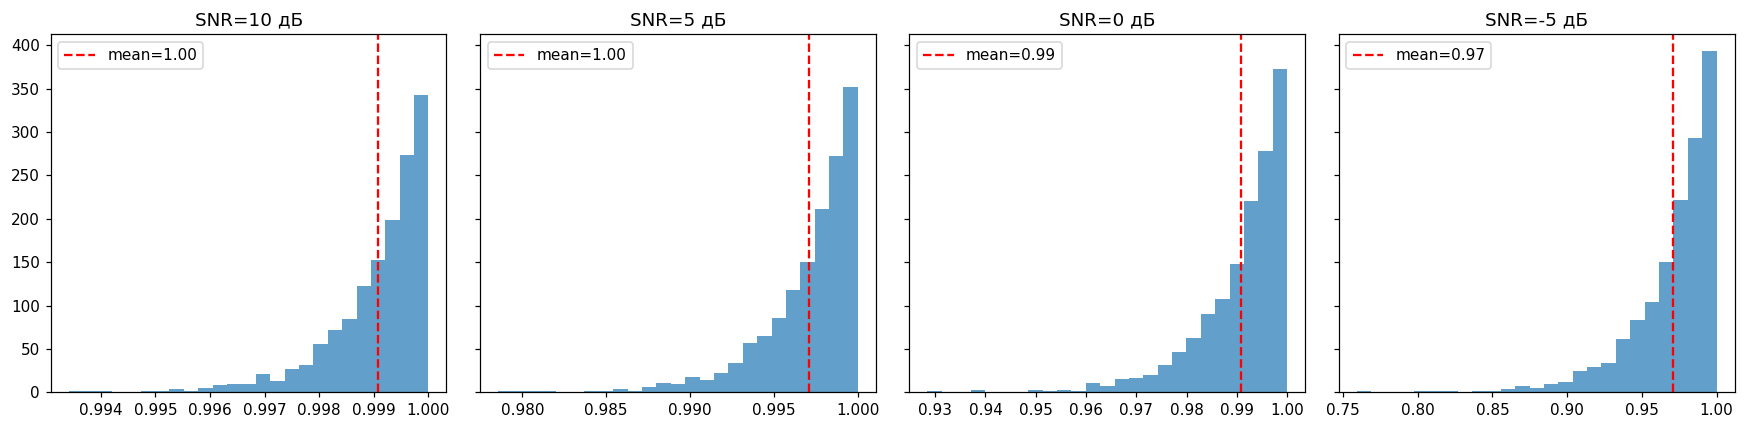

Confidence падает с SNR. Адаптивный порог = f(текущий SNR) надёжнее фиксированного.
В нашем модеме: используем отношение энергий mark/space — самонормирующееся.


In [7]:
# собираем статистику confidence при разных SNR
snr_range = [10, 5, 0, -5]
fig, axes = plt.subplots(1, len(snr_range), figsize=(16, 4), sharey=True)
for i, snr in enumerate(snr_range):
    confs = []
    for t in range(15):
        fsk = m.generate_fsk(m.packet_encode(b'test'), MARK, SPACE, BAUD)
        frame = np.concatenate([chirp, fsk])
        rx = m.add_awgn(frame, snr, seed=t)
        corr, peak, val = m.cross_correlate(rx, chirp)
        if val > 0.3:
            _, conf = m.fsk_demodulate(rx[peak+chirp_len:], MARK, SPACE, BAUD)
            confs.extend(conf)
    axes[i].hist(confs, bins=25, alpha=0.7)
    axes[i].axvline(np.mean(confs), color='r', ls='--', label=f'mean={np.mean(confs):.2f}')
    axes[i].set_title(f'SNR={snr} дБ'); axes[i].legend()
plt.tight_layout(); plt.show()
print('Confidence падает с SNR. Адаптивный порог = f(текущий SNR) надёжнее фиксированного.')
print('В нашем модеме: используем отношение энергий mark/space — самонормирующееся.')

## ✅ Выводы Lab 4

1. **Reed-Solomon(51,35) исправляет ровно до 8 байт ошибок** — теория (nsym/2) совпала с практикой: 8/8 восстановлено, 9 — никогда.
2. **Против AWGN-шума RS не сдвигает порог** (~ -10 дБ у обоих): ошибки FSK в шуме пачками > 8 байт. RS окупается против burst-ошибок (4.3).
3. **Interleaving критичен против burst-ошибок** — burst 30 байт без него убивает блок (7/8), с ним размазывается по 3-4 байта/блок и полностью исправляется (8/8).
4. **Bandpass фильтр 900-2500 Гц улучшает SNR на ~11.5 дБ** — теория 10·log10(24000/1600)=11.8 дБ, измерено 11.4-11.6 дБ.
5. **Узкополосная помеха на частоте сигнала сильнее его — фатальна** (confidence падает до 0.5, CRC не сходится). Защита: смена частот (frequency hopping); внеполосная помеха снимается BPF.
6. **Отношение энергий mark/space самонормируется** — не нужен фиксированный порог.

**Стек помехоустойчивости готов**: BPF → FSK → RS + Interleave. Пакеты надёжны до SNR ≈ -10 дБ (как в Lab 3).